In [1]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
from tqdm import tqdm
tqdm.pandas()

# check if GPU is available - your RTX 4060 should show here
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

c:\Users\amirh\Documents\projects\youtube-intelligence-engine\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
Device: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
df = pd.read_csv("../data/processed/comments_preprocessed.csv")

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model = model.to("cuda")

print("Model loaded on:", next(model.parameters()).device)
print("comments to analyze: ", len(df))

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8952.58it/s]


Model loaded on: cuda:0
comments to analyze:  27330


In [7]:
labels = ["negative", "neutral", "positive"]

def get_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return pd.Series({"sentiment": "neutral", "score_negative": 0.0, 
                          "score_neutral": 1.0, "score_positive": 0.0, "confidence": 1.0})
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to("cuda")
    with torch.no_grad():
        scores = model(**inputs).logits[0].cpu().numpy()
    probs = softmax(scores)
    label = labels[probs.argmax()]
    return pd.Series({
        "sentiment": label,
        "score_negative": round(float(probs[0]), 4),
        "score_neutral":  round(float(probs[1]), 4),
        "score_positive": round(float(probs[2]), 4),
        "confidence":     round(float(probs.max()), 4)
    })

In [8]:
sentiment_results = df["text_clean"].progress_apply(get_sentiment)
df = pd.concat([df, sentiment_results], axis=1)

print("Done.")
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())
print("\nDistribution %:")
print(df["sentiment"].value_counts(normalize=True).round(3) * 100)

100%|██████████| 27330/27330 [07:31<00:00, 60.50it/s]

Done.

Sentiment distribution:
sentiment
negative    12917
neutral      9457
positive     4956
Name: count, dtype: int64

Distribution %:
sentiment
negative    47.3
neutral     34.6
positive    18.1
Name: proportion, dtype: float64


In [9]:
sentiment_by_video = df.groupby("video_name")["sentiment"].value_counts(normalize=True).round(3) * 100
print(sentiment_by_video)

video_name                  sentiment
ai_fails_96_percent         negative     51.4
                            neutral      33.5
                            positive     15.1
ai_might_not_replace_jobs   negative     53.3
                            neutral      33.8
                            positive     12.8
ai_slop_renaissance         positive     46.2
                            negative     27.1
                            neutral      26.7
ai_white_collar_12months    negative     40.4
                            neutral      36.4
                            positive     23.1
capitalism_no_workers       negative     54.8
                            neutral      38.0
                            positive      7.2
replacing_developers_wrong  negative     55.5
                            neutral      33.0
                            positive     11.5
replacing_humans_wrong      negative     45.8
                            neutral      35.0
                            positive     1

In [10]:
df.to_csv("../data/processed/comments_sentiment.csv", index=False, encoding="utf-8-sig")

print(f"Saved {len(df)} rows to data/processed/comments_sentiment.csv")
print("Columns:", df.columns.tolist())

Saved 27330 rows to data/processed/comments_sentiment.csv
Columns: ['video_id', 'video_name', 'comment_id', 'author', 'text', 'likes', 'published_at', 'reply_count', 'text_clean', 'text_lemma', 'sentiment', 'score_negative', 'score_neutral', 'score_positive', 'confidence']


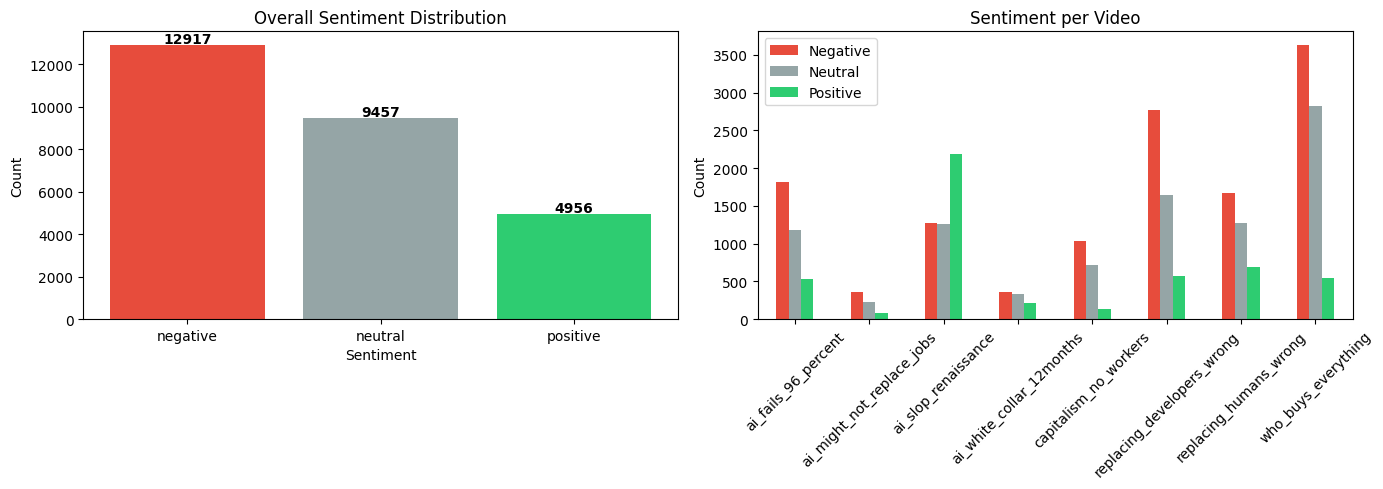

Chart saved.


: 

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# overall distribution
sentiment_counts = df["sentiment"].value_counts()
colors = ["#e74c3c", "#95a5a6", "#2ecc71"]
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[0].set_title("Overall Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 100, str(v), ha="center", fontweight="bold")

# per video breakdown
video_sentiment = df.groupby(["video_name", "sentiment"]).size().unstack(fill_value=0)
video_sentiment.plot(kind="bar", ax=axes[1], color=colors, rot=45)
axes[1].set_title("Sentiment per Video")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].legend(["Negative", "Neutral", "Positive"])

plt.tight_layout()
plt.savefig("../data/processed/sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")